In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
v2_benchmark_data = pd.read_csv("results/nwmapiv2/combine_api2_results.csv")
v2_benchmark_data.head()

,scenario,case,filter,elapsed_time_seconds,bytes_processed,job_id
0,retrospectives,case_01,HUC-0305010505,5.832636,1160000.0,8931e2bd-7403-4e49-947e-3d6a4aa61bc0
1,retrospectives,case_01,HUC-030501050505,1.599326,824.0,15a77a0d-93d3-4d88-aa7b-4217b9d43a19
2,retrospectives,case_01,Reach-12034579,1.283794,182.0,fff996d8-eda3-403a-a306-6b92ab8fc695
3,retrospectives,case_02,HUC-0305010505,9.580900,1160000.0,66d7cb13-7f2a-456b-82a2-a1ab73fb3fa0
4,retrospectives,case_02,HUC-030501050505,1.941154,824.0,9bc7bf19-fd76-4e4e-8c95-3ee5575b7bc1


In [3]:
v2_benchmark_data['scenario'].unique()

array(['retrospectives', 'analyses-assim', 'short_range_forecast',
       'medium_range_forecast', 'long_range_forecast', 'return_periods',
       'geometries', 'flow-metrics', 'percentile-flows',
       'geometries_with_geom_filter', 'geometries_with_bbox',
       'geometries_with_bbox_and_stream_order_filter'], dtype=object)

In [4]:
v2_benchmark_data_comp1 = v2_benchmark_data[v2_benchmark_data['scenario'].isin(['geometries', 'geometries_with_geom_filter', 'geometries_with_bbox', 'geometries_with_bbox_and_stream_order_filter'])]

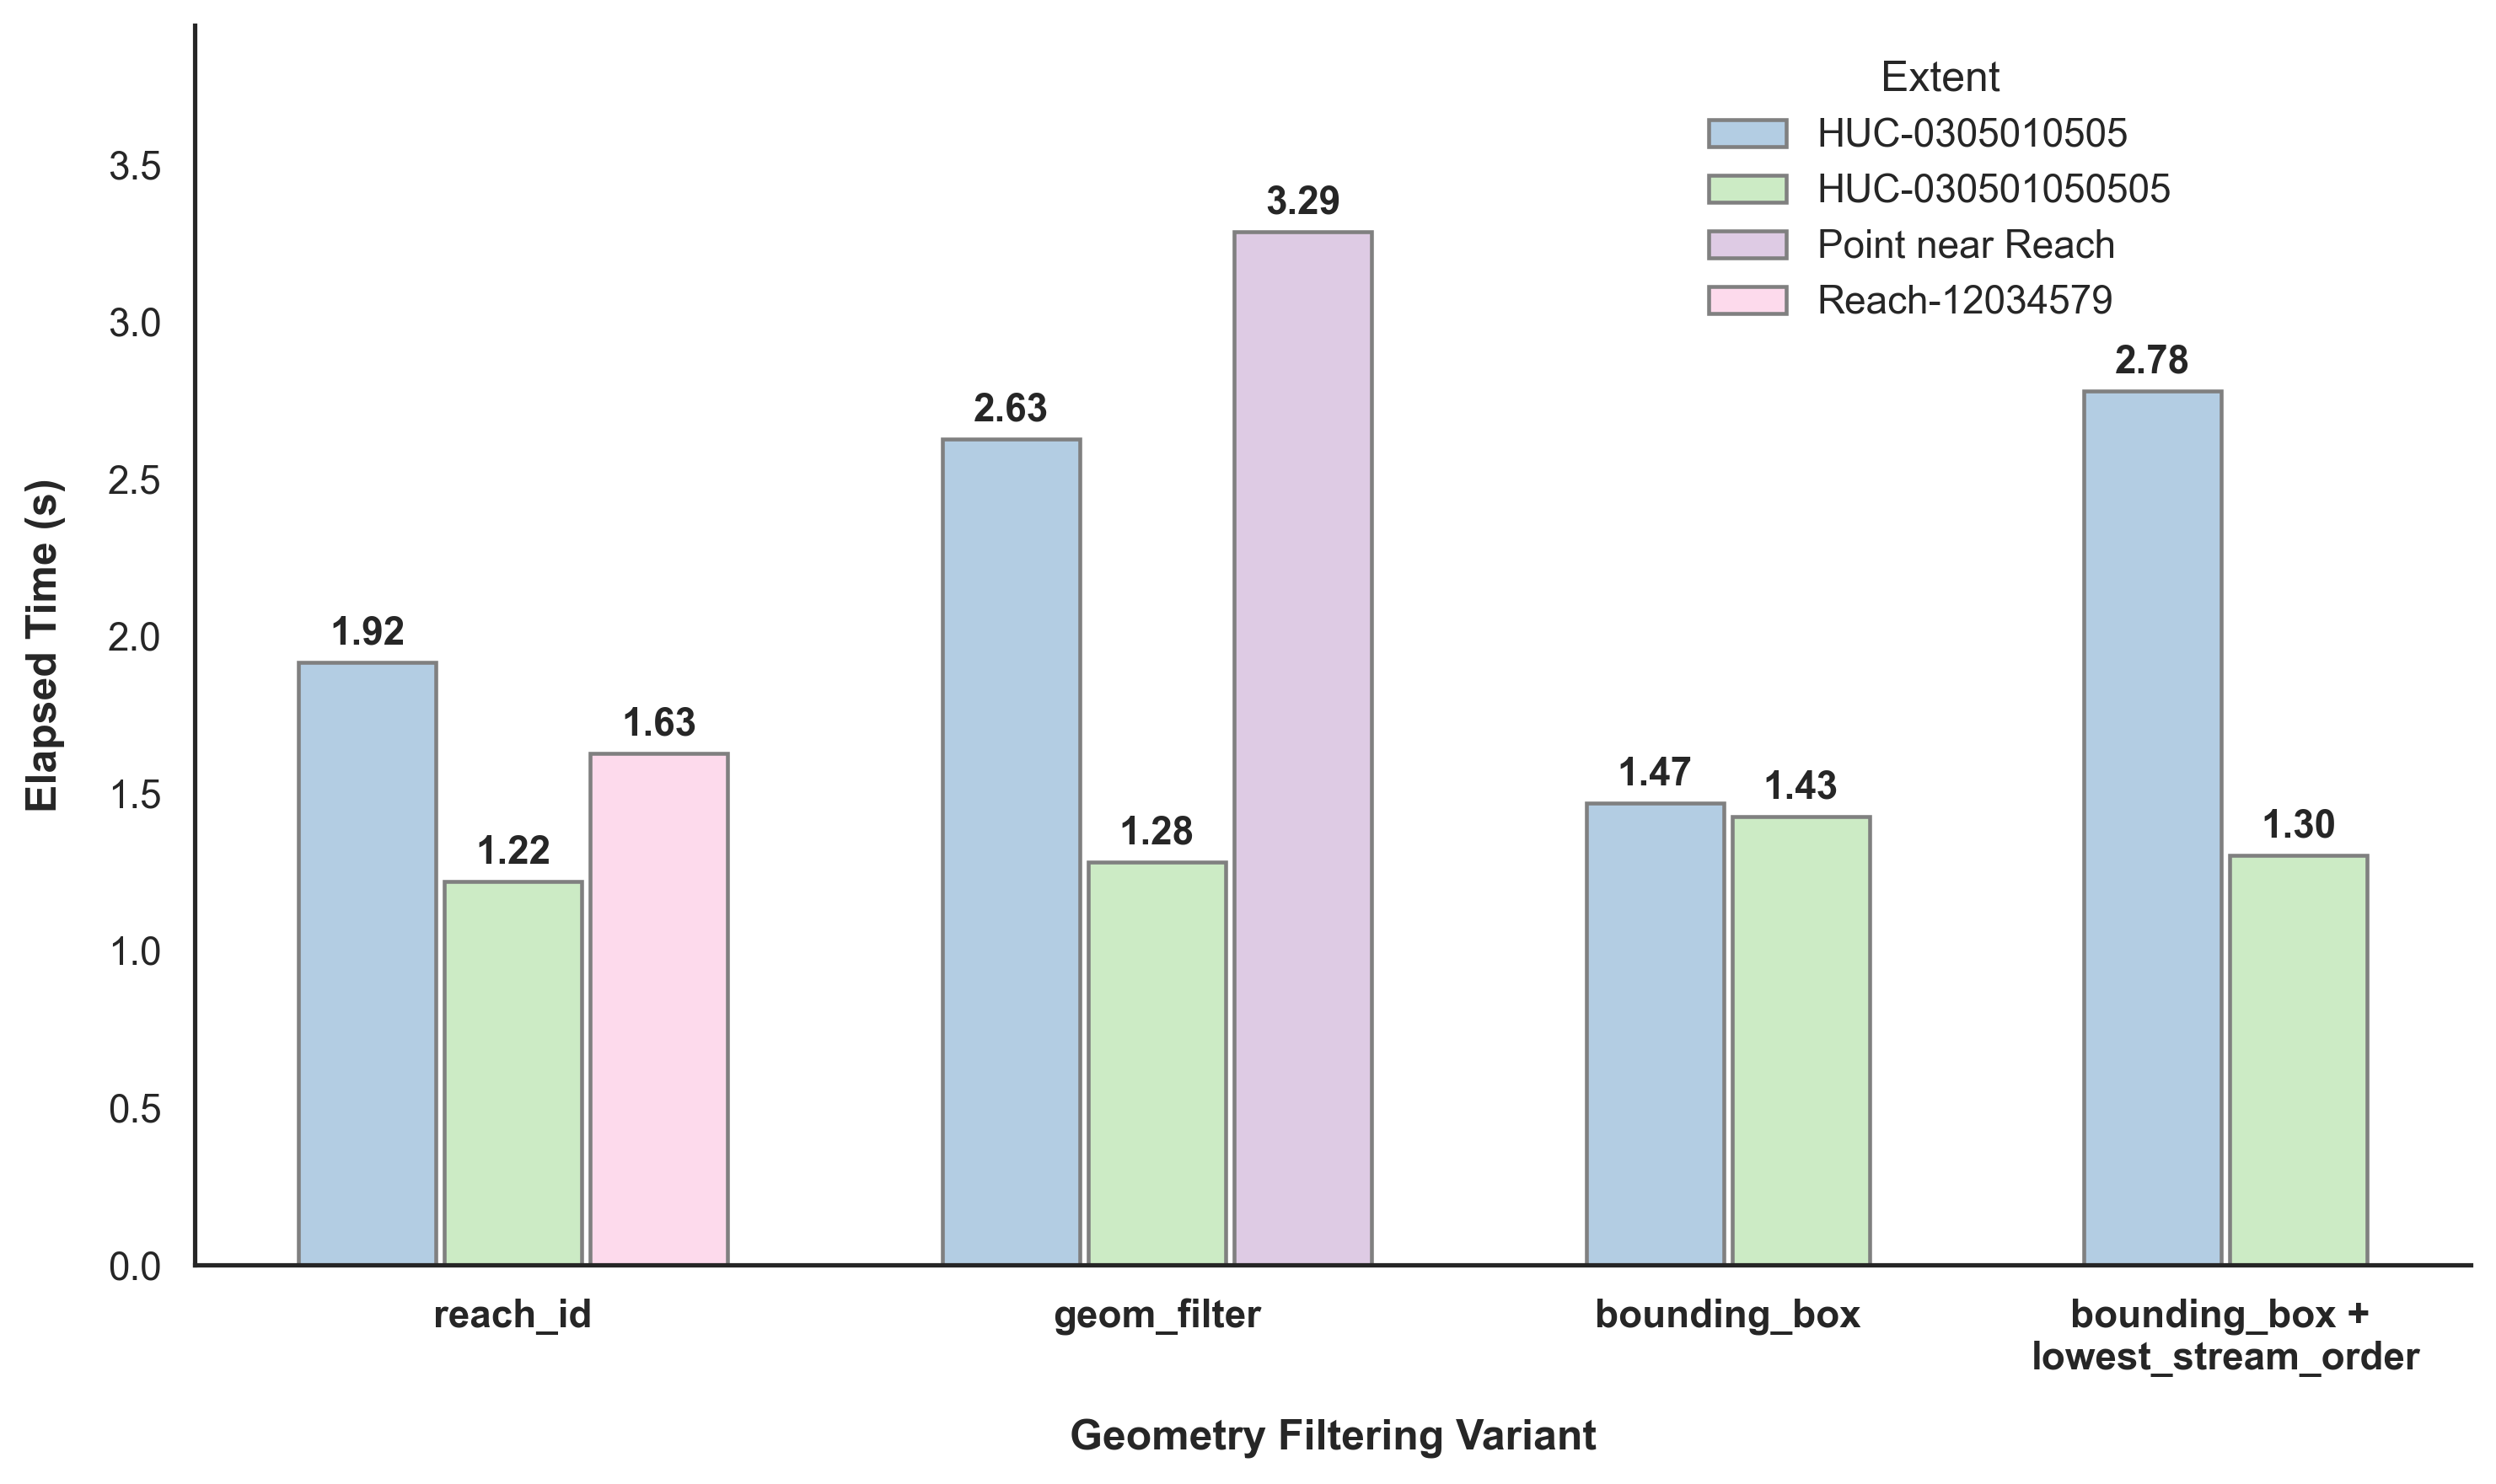

In [5]:
cluster_name_map = {
    'geometries': 'reach_id',
    'geometries_with_geom_filter': 'geom_filter',
    'geometries_with_bbox': 'bounding_box',
    'geometries_with_bbox_and_stream_order_filter': 'bounding_box + \nlowest_stream_order'
}
sns.set_theme(style="white")
plt.rcParams.update({'font.size': 11, 'figure.dpi': 300, 'font.family': 'sans-serif'})

bar_width, inter_bar_gap, cluster_gap = 0.8, 0.05, 1.2
unique_filters = sorted(v2_benchmark_data_comp1['filter'].unique())
palette = sns.color_palette("Pastel1", len(unique_filters)+4)
palette = [palette[1], palette[2], palette[3], palette[7]]
color_map = dict(zip(unique_filters, palette))

fig, ax = plt.subplots(figsize=(10, 6))
current_x = 0
scenario_ticks, scenario_labels, legend_handles = [], [], {}

for scenario_id in v2_benchmark_data_comp1['scenario'].unique():
    subset = v2_benchmark_data_comp1[v2_benchmark_data_comp1['scenario'] == scenario_id]
    start_cluster_x = current_x
    
    for i, (_, row) in enumerate(subset.iterrows()):
        f_type = row['filter']
        val = row['elapsed_time_seconds']

        bar_container = ax.bar(current_x, val, width=bar_width, color=color_map[f_type], 
                               edgecolor='grey', linewidth=1.1)
        
        ax.bar_label(bar_container, fmt='%.2f', padding=3, fontweight='bold')
        
        if f_type not in legend_handles:
            legend_handles[f_type] = bar_container[0]
        current_x += (bar_width + inter_bar_gap)
    
    end_cluster_x = current_x - (bar_width + inter_bar_gap)
    scenario_ticks.append((start_cluster_x + end_cluster_x) / 2)
    scenario_labels.append(cluster_name_map.get(scenario_id, scenario_id))
    current_x += cluster_gap

ax.set_xticks(scenario_ticks)
ax.set_xticklabels(scenario_labels, fontweight='bold')
ax.set_xlabel('Geometry Filtering Variant', fontweight='bold', labelpad=12)
ax.set_ylabel('Elapsed Time (s)', fontweight='bold', labelpad=12)
ax.set_ylim(0, v2_benchmark_data_comp1['elapsed_time_seconds'].max() * 1.2)

sorted_f = sorted(legend_handles.keys())
ax.legend([legend_handles[k] for k in sorted_f], sorted_f, title='Extent', 
          bbox_to_anchor=(0.65, 1), loc='upper left', frameon=False)

sns.despine()
plt.tight_layout()

plt.savefig("figures/comparison_of_filtering_variants.png", dpi=300)
plt.savefig("figures/comparison_of_filtering_variants.pdf", dpi=300)
plt.show()

In [6]:
v2_benchmark_data_comp2 = v2_benchmark_data[v2_benchmark_data['scenario'].isin(['retrospectives', 'percentile-flows'])]
v2_benchmark_data_comp2 = v2_benchmark_data_comp2.query("not (case == 'case_02' and scenario == 'retrospectives')")
v2_benchmark_data_comp2.head()

,scenario,case,filter,elapsed_time_seconds,bytes_processed,job_id
0,retrospectives,case_01,HUC-0305010505,5.832636,1160000.0,8931e2bd-7403-4e49-947e-3d6a4aa61bc0
1,retrospectives,case_01,HUC-030501050505,1.599326,824.0,15a77a0d-93d3-4d88-aa7b-4217b9d43a19
2,retrospectives,case_01,Reach-12034579,1.283794,182.0,fff996d8-eda3-403a-a306-6b92ab8fc695
6,retrospectives,case_03,HUC-0305010505,5.423053,NaN,NaN
7,retrospectives,case_03,HUC-030501050505,1.519760,NaN,NaN


In [7]:
v2_benchmark_data_comp2.loc[(v2_benchmark_data_comp2['scenario'] == 'retrospectives') & (v2_benchmark_data_comp2['case'] == 'case_01'), 'case'] = 'Base case \n(ordered=False, \nmetadata=False, \noutput_format=csv)'
v2_benchmark_data_comp2.loc[(v2_benchmark_data_comp2['scenario'] == 'retrospectives') & (v2_benchmark_data_comp2['case'] == 'case_03'), 'case'] = 'ordered=True'
v2_benchmark_data_comp2.loc[(v2_benchmark_data_comp2['scenario'] == 'retrospectives') & (v2_benchmark_data_comp2['case'] == 'case_04'), 'case'] = 'metadata=True'
v2_benchmark_data_comp2.loc[(v2_benchmark_data_comp2['scenario'] == 'retrospectives') & (v2_benchmark_data_comp2['case'] == 'case_05'), 'case'] = 'output_format=json'
v2_benchmark_data_comp2.loc[(v2_benchmark_data_comp2['scenario'] == 'retrospectives') & (v2_benchmark_data_comp2['case'] == 'case_06'), 'case'] = 'output_format=geojson'
v2_benchmark_data_comp2.loc[(v2_benchmark_data_comp2['scenario'] == 'retrospectives') & (v2_benchmark_data_comp2['case'] == 'case_07'), 'case'] = 'output_format=geopackage \n(or shapefile)'


In [8]:
v2_benchmark_data_comp2.loc[(v2_benchmark_data_comp2['scenario'] == 'percentile-flows') & (v2_benchmark_data_comp2['case'] == 'case_01'), 'case'] = 'Base case \n(ordered=False, \nmetadata=False, \noutput_format=csv)'
v2_benchmark_data_comp2.loc[(v2_benchmark_data_comp2['scenario'] == 'percentile-flows') & (v2_benchmark_data_comp2['case'] == 'case_02'), 'case'] = 'ordered=True'
v2_benchmark_data_comp2.loc[(v2_benchmark_data_comp2['scenario'] == 'percentile-flows') & (v2_benchmark_data_comp2['case'] == 'case_03'), 'case'] = 'metadata=True'
v2_benchmark_data_comp2.loc[(v2_benchmark_data_comp2['scenario'] == 'percentile-flows') & (v2_benchmark_data_comp2['case'] == 'case_04'), 'case'] = 'output_format=json'
v2_benchmark_data_comp2.loc[(v2_benchmark_data_comp2['scenario'] == 'percentile-flows') & (v2_benchmark_data_comp2['case'] == 'case_05'), 'case'] = 'output_format=geojson'
v2_benchmark_data_comp2.loc[(v2_benchmark_data_comp2['scenario'] == 'percentile-flows') & (v2_benchmark_data_comp2['case'] == 'case_06'), 'case'] = 'output_format=shapefile'


In [9]:
original_order = v2_benchmark_data_comp2['case'].unique()
original_order

array(['Base case \n(ordered=False, \nmetadata=False, \noutput_format=csv)',
       'ordered=True', 'metadata=True', 'output_format=json',
       'output_format=geojson',
       'output_format=geopackage \n(or shapefile)',
       'output_format=shapefile'], dtype=object)

In [10]:
v2_benchmark_data_comp2['case'] = pd.Categorical(
    v2_benchmark_data_comp2['case'], 
    categories=original_order, 
    ordered=True
)

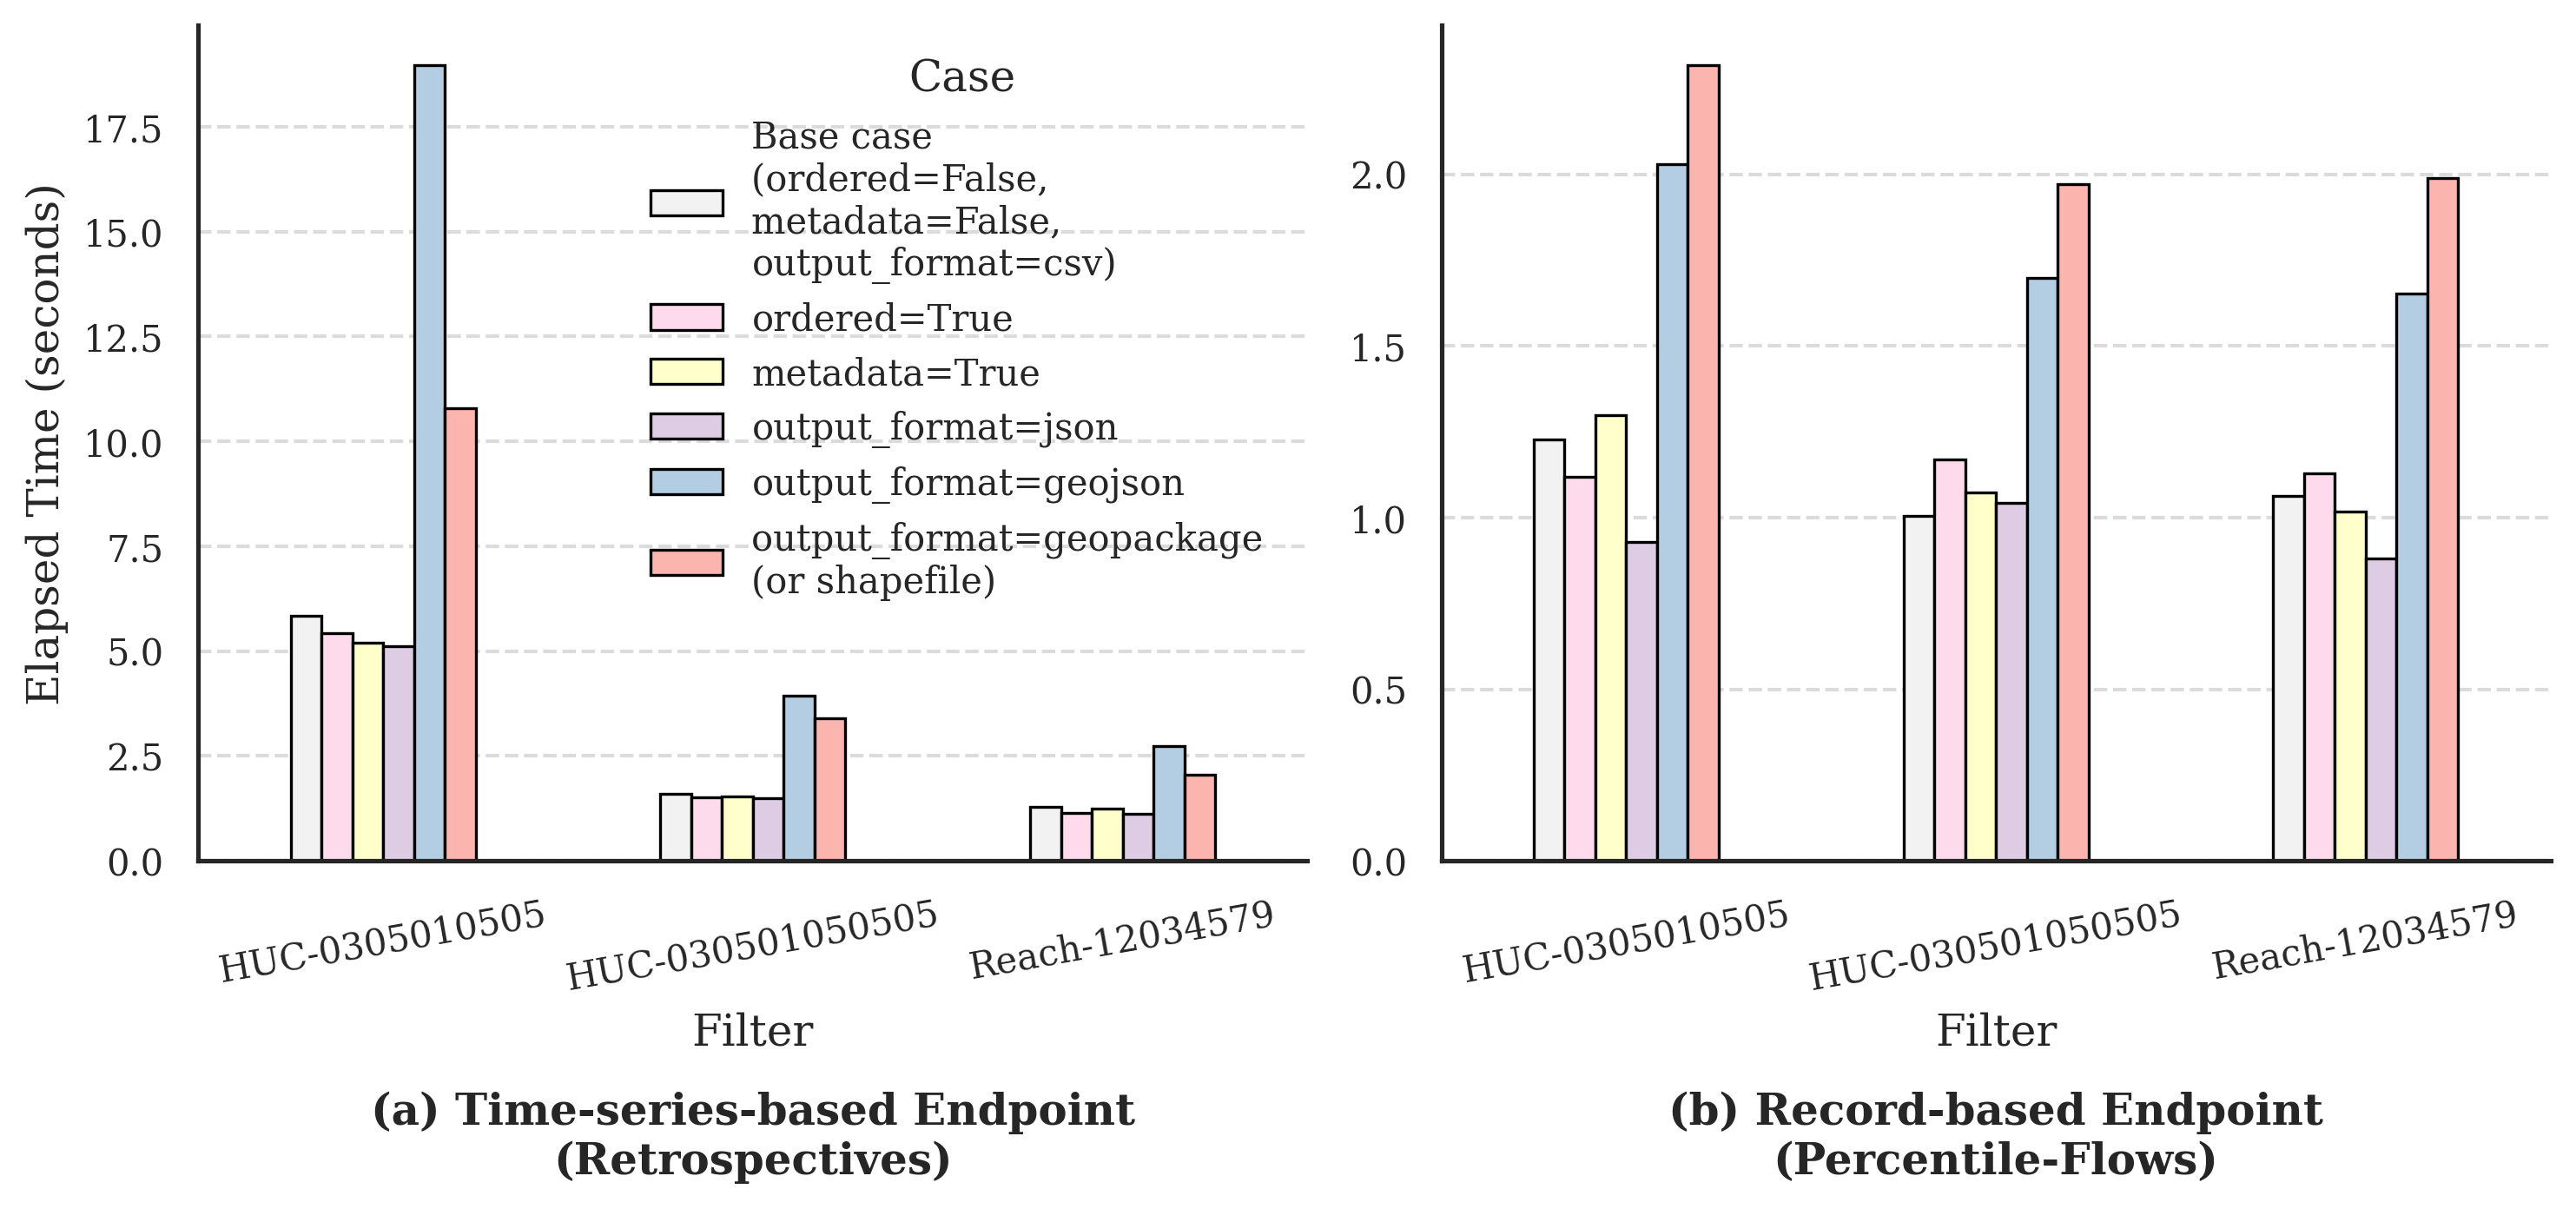

In [11]:
plt.rcParams.update({
    "font.family": "serif",     
    "font.size": 10,             
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "savefig.dpi": 300           
})


fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=False)
scenarios = v2_benchmark_data_comp2['scenario'].unique()

for i, scenario in enumerate(scenarios):
    ax = axes[i]
    scenario_df = v2_benchmark_data_comp2[v2_benchmark_data_comp2['scenario'] == scenario]
    plot_data = scenario_df.pivot(index='filter', columns='case', values='elapsed_time_seconds')

    plot_data.plot(kind='bar', 
                   ax=ax, 
                   capsize=4, 
                   cmap='Pastel1_r', 
                   edgecolor='black', 
                   linewidth=0.8,
                   rot=0)
    
    ax.set_xlabel("Filter")
    if i == 0:
        ax.set_ylabel("Elapsed Time (seconds)")
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    if i == 0:
        ax.legend(title='Case', frameon=False,)
        ax.set_title(f"(a) Time-series-based Endpoint\n(Retrospectives)", fontweight='bold', y=-0.4,)
    else:
        ax.legend().set_visible(False)
        ax.set_title(f"(b) Record-based Endpoint\n(Percentile-Flows)", fontweight='bold', y=-0.4)
    ax.tick_params(axis='x', rotation=10)

plt.tight_layout()

plt.savefig('figures/compare_effect_of_additional_filters.pdf', format='pdf', bbox_inches='tight')
plt.savefig('figures/compare_effect_of_additional_filters.png', format='png', bbox_inches='tight')
plt.show()